In [42]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

In [7]:
go = OBO('../data/geneontology/go.obo', store_as_int=True)

In [10]:
def read_fantasia():
    def read(sp):
        fn = '../data/functional_predictions/fantasia/results/' + sp + '/results_' + sp + '.csv.gz'
        df = pd.read_csv(fn)
        return df
    def read_all():
        for sp in tqdm(os.listdir('../data/functional_predictions/fantasia/results')):
            yield read(sp)

    return pd.concat(read_all())

fantasia_df = read_fantasia()

  0%|          | 0/64 [00:00<?, ?it/s]

In [14]:
fantasia_df1 = fantasia_df[['query_accession', 'uniprot_accession', 'reliability_index', 'distance']].drop_duplicates()

In [16]:
# plot reliability index vs distance

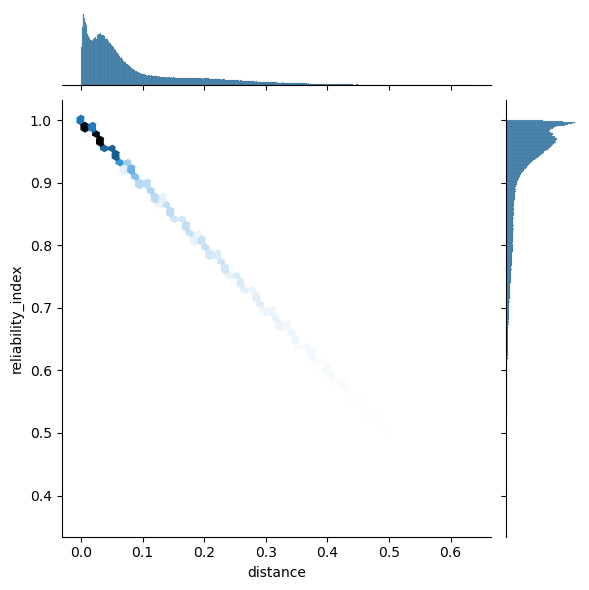

In [21]:
sns.jointplot(data=fantasia_df1, y='reliability_index', x='distance', kind='hex')

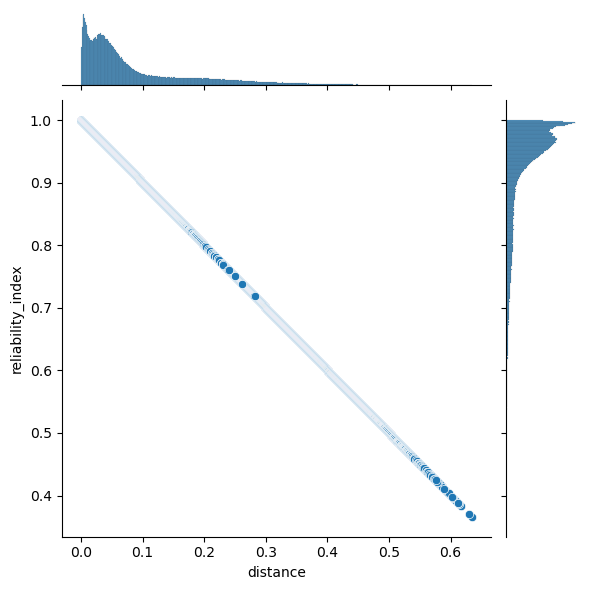

In [22]:
sns.jointplot(data=fantasia_df1, y='reliability_index', x='distance')

In [392]:
fantasia_df1.reliability_index.median()

0.9468114078044891

In [24]:
fantasia_df1['species'] = fantasia_df1['query_accession'].apply(lambda x: x[:5])

In [29]:
from dendropy import Tree

In [35]:
t = Tree.get(path='../labelled_trees/tree_c.nwk', schema='newick')
t.ladderize()
order = [n.taxon.label for n in t.leaf_nodes()]
sp2i = {sp: i for (i, sp) in  enumerate(order)}

In [36]:
fantasia_df1['species_order'] = fantasia_df1['species'].map(sp2i)

In [39]:
fantasia_df1 = fantasia_df1.sort_values('species_order')

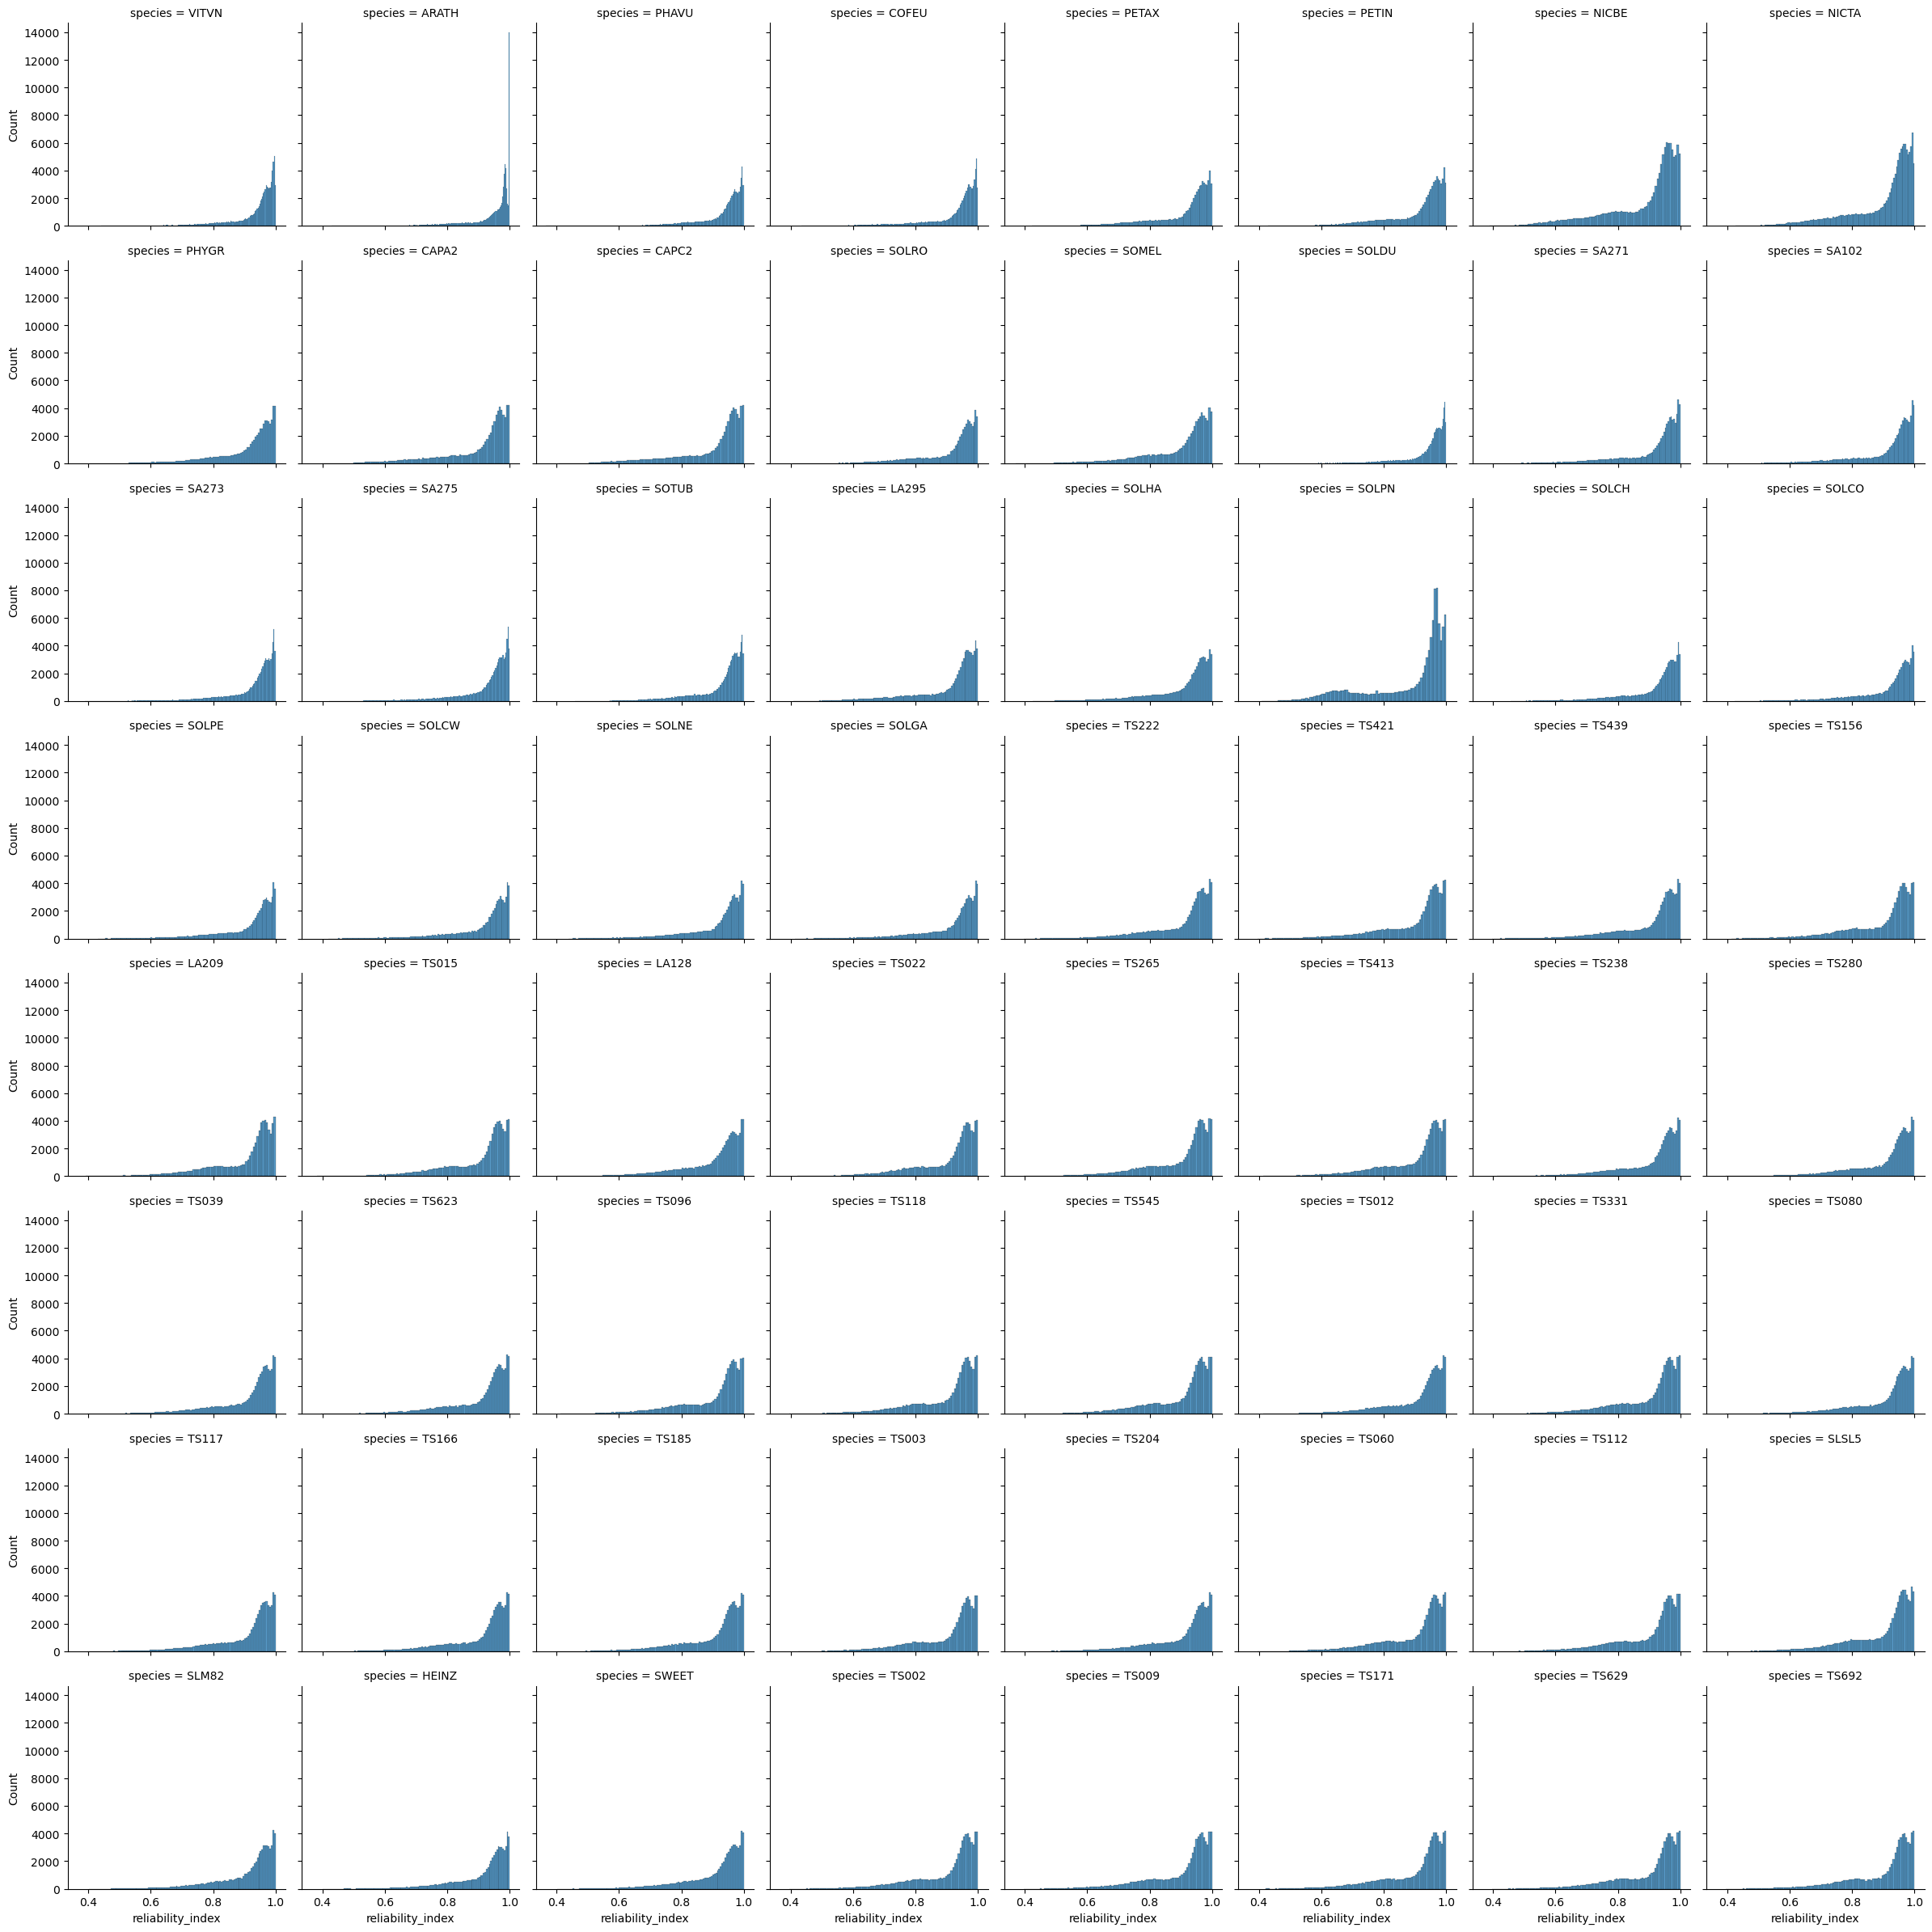

In [43]:
g = sns.FacetGrid(fantasia_df1, col="species", col_wrap=8)
g.map(sns.histplot, 'reliability_index')
plt.savefig('../fantasia_reliability_score.pdf')

In [46]:
fantasia_df1

,query_accession,uniprot_accession,reliability_index,distance,species,species_order
220137,VITVNXP_059593584.1,A0A9E7LUJ4,0.987597,0.012403,VITVN,0
100970,VITVNXP_010660842.1,Q9SS90,0.883914,0.116086,VITVN,0
100977,VITVNXP_002274649.1,Q9LQZ7,0.883848,0.116152,VITVN,0
100982,VITVNXP_059595183.1,Q1G3Q4,0.883846,0.116154,VITVN,0
100986,VITVNXP_002264133.2,Q6NPL4,0.883830,0.116170,VITVN,0
...,...,...,...,...,...,...
168887,TS692Solyc_TS692_02T003126.1,Q91YP2,0.979789,0.020211,TS692,63
168892,TS692Solyc_TS692_02T001322.2,B4XT64,0.979788,0.020212,TS692,63
168898,TS692Solyc_TS692_02T002986.1,O80462,0.979788,0.020212,TS692,63
168867,TS692Solyc_TS692_03T002390.1,Q9XHP2,0.979806,0.020194,TS692,63


In [108]:
ts = {str(go[t]) for t in go.children('GO:0016117', include_self=True)}

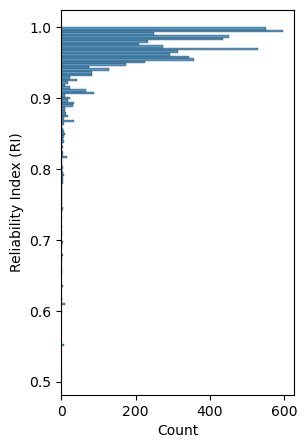

In [126]:
!mkdir -p  ../figures
(fig, ax) = plt.subplots(figsize=(3,5))
ax = sns.histplot(data=fantasia_df[fantasia_df.go_id.isin(ts)], y='reliability_index', ax=ax)
ax.set_ylabel('Reliability Index (RI)')
plt.savefig('../figures/ri_dist_carotenoid.png', bbox_inches='tight')
plt.savefig('../figures/ri_dist_carotenoid.pdf', bbox_inches='tight')

In [97]:
all_uniprot = set(fantasia_df[fantasia_df.go_id.isin(ts)].uniprot_accession)

In [98]:
from collections import Counter
all_uniprot_counts = Counter(fantasia_df[fantasia_df.go_id.isin(ts)].uniprot_accession)

In [71]:
from bioservices import UniProt

u = UniProt(verbose=False)

In [101]:
def gen():
    for x in tqdm(all_uniprot):
        z = u.retrieve(x, frmt='json')
        r = {'uniprotkb_acc': x,
             'uniprotkb_id': z['uniProtkbId'],
             'species': z['organism']['scientificName'],
             'count': all_uniprot_counts[x]}
        r['species_code'] = r['uniprotkb_id'].split('_')[1]
        try:
            r['gene_symbol'] = z['genes'][0]['geneName']['value']
        except:
            r['gene_symbol'] = '-'
        try:
            r['gene_desc'] = z['proteinDescription']['recommendedName']['fullName']['value']
        except:
            r['gene_desc'] = '-'
        yield r

df = pd.DataFrame(gen())

  0%|          | 0/39 [00:00<?, ?it/s]

In [102]:
df.to_csv('../data/functional_predictions/fantasia/carotenoid_genes.tsv', sep='\t', index=False)

In [140]:
from collections import Counter, defaultdict
from dendropy import Tree
from tqdm.auto import tqdm
import itertools
import os
import pandas as pd
import pyham
import sys

fastoma_results_path = '../fastoma_round2_tree_c/result/'

In [141]:
# load the tree and get all the branches
nwk_fn = os.path.join(fastoma_results_path, 'species_tree_checked_relabelled.nwk')
t = Tree.get(path=nwk_fn, schema='newick')

key_nodes = list(filter(lambda n: '.' not in n.label, t.internal_nodes()))
species_level_paths = defaultdict(list)
onestep_higher_paths = defaultdict(list)

for n in key_nodes:
    # get species below
    for leaf in map(lambda n: n.taxon.label, n.leaf_nodes()):
        species_level_paths[n.label].append((n.label, leaf))

    # find species and then get set of nodes one step higher
    for n2 in set(map(lambda n1: n1.parent_node, n.leaf_nodes())):
        if n.label != n2.label:
            onestep_higher_paths[n.label].append((n.label, n2.label))

In [142]:
# orthoxml
ham = pyham.Ham(
            tree_file=nwk_fn,
            tree_format="newick",
            hog_file=os.path.join(fastoma_results_path, 'FastOMA_HOGs.orthoxml'),
            type_hog_file="orthoxml",
            filter_object=None,
            use_internal_name=True,
            with_parser_progress=True,
        )

Parsing Species: 0it [00:00, ?it/s]

Parsing HOGs: 0it [00:00, ?it/s]

In [146]:
carotenoid_preds = fantasia_df[fantasia_df.go_id.isin(ts)]

In [148]:
carotenoid_preds.iloc[:1]

,query_accession,reference_id,model_key,distance,reliability_index,distance_metric,uniprot_accession,go_id,category,go_description,evidence_codes
306,TS204Solyc_TS204_07T002173.1,42383,Prot-T5,0.011911,0.988089,cosine,O24023,GO:0016123,P,xanthophyll biosynthetic process,IMP


In [266]:
def get_hog_id(x):
    try:
        g = ham.get_genes_by_external_id(x)[0]
    except:
        return None
    if g.is_singleton():
        return '-'
    p = g.parent
    while p.hog_id is None:
        p = p.parent
    return p.hog_id.split('_')[0]

def get_root_hog_id(x):
    try:
        g = ham.get_genes_by_external_id(x)[0]
    except:
        return 'filtered'
        
    if g.is_singleton():
        return 'singleton'
        
    return g.get_top_level_hog().hog_id.split('_')[0]

In [268]:
carotenoid_preds['subhog_id'] = carotenoid_preds['query_accession'].apply(get_hog_id)
carotenoid_preds['roothog_id'] = carotenoid_preds['query_accession'].apply(get_root_hog_id)

/tmp/ipykernel_1758404/4205673351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carotenoid_preds['subhog_id'] = carotenoid_preds['query_accession'].apply(get_hog_id)
/tmp/ipykernel_1758404/4205673351.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carotenoid_preds['roothog_id'] = carotenoid_preds['query_accession'].apply(get_root_hog_id)


In [269]:
carotenoid_preds

,query_accession,reference_id,model_key,distance,reliability_index,distance_metric,uniprot_accession,go_id,category,go_description,evidence_codes,subhog_id,roothog_id
306,TS204Solyc_TS204_07T002173.1,42383,Prot-T5,0.011911,0.988089,cosine,O24023,GO:0016123,P,xanthophyll biosynthetic process,IMP,HOG:0037743.1b,HOG:0037743
316,TS204Solyc_TS204_07T002173.1,42383,Prot-T5,0.011911,0.988089,cosine,O24023,GO:1901812,P,beta-carotene biosynthetic process,IMP,HOG:0037743.1b,HOG:0037743
741,TS204Solyc_TS204_06T002371.1,47989,Prot-T5,0.014378,0.985622,cosine,K4C9E2,GO:0016123,P,xanthophyll biosynthetic process,IDA,HOG:0008619.4c,HOG:0008619
759,TS204Solyc_TS204_12T001558.1,75712,Prot-T5,0.014458,0.985542,cosine,K4DEY3,GO:0016123,P,xanthophyll biosynthetic process,IMP,HOG:0029666,HOG:0029666
1532,TS204Solyc_TS204_04T000922.1,48344,Prot-T5,0.016681,0.983319,cosine,Q43415,GO:1901812,P,beta-carotene biosynthetic process,IDA,HOG:0008619.4d,HOG:0008619
...,...,...,...,...,...,...,...,...,...,...,...,...,...
212758,CAPA2PHT95342.1,19318,Ankh3-Large,0.047217,0.952783,cosine,Q38932,GO:0016117,P,carotenoid biosynthetic process,IMP,HOG:0009047,HOG:0009047
212759,CAPA2PHT95342.1,19318,Ankh3-Large,0.047217,0.952783,cosine,Q38932,GO:0016123,P,xanthophyll biosynthetic process,IGI,HOG:0009047,HOG:0009047
218022,CAPA2PHT90787.1,19318,Ankh3-Large,0.051531,0.948469,cosine,Q38932,GO:0016117,P,carotenoid biosynthetic process,IMP,HOG:0006828.2b,HOG:0006828
218023,CAPA2PHT90787.1,19318,Ankh3-Large,0.051531,0.948469,cosine,Q38932,GO:0016123,P,xanthophyll biosynthetic process,IGI,HOG:0006828.2b,HOG:0006828


In [290]:
zdf =pd.merge(carotenoid_preds, df, left_on='uniprot_accession', right_on='uniprotkb_acc')

In [308]:
from collections import Counter
roothog_counts = Counter([tuple(x) for x in zdf[['uniprotkb_acc', 'roothog_id']].values if x[1] not in {'filtered', 'singleton'}])
roothog_genesym_counts = Counter([tuple(x) for x in zdf[['gene_symbol', 'roothog_id']].values if x[1] not in {'filtered', 'singleton'}])

In [309]:
zdf['uniprotkb_acc_count'] = zdf.apply(lambda x: roothog_counts[(x.uniprotkb_acc, x.roothog_id)], axis=1)
zdf['gene_symbol_count'] = zdf.apply(lambda x: roothog_genesym_counts[(x.gene_symbol, x.roothog_id)], axis=1)

In [314]:
head = list(df.keys()) + ['roothog_id', 'subhog_id', 'uniprotkb_acc_count', 'gene_symbol_count']

In [325]:
zdf[head].sort_values(['roothog_id', 'gene_symbol_count', 'uniprotkb_acc_count'], ascending=[True, False, False]).to_csv('../data/functional_predictions/fantasia/carotenoid_genes_hogs_tree_c.tsv', sep='\t')

In [311]:
for (hog_id, zzdf) in zdf[head].groupby('roothog_id'):
    #print(hog_id, len(zzdf), len(set(zzdf.gene_symbol)))
    if len(set(zzdf.gene_symbol)) > 1:
        gene_syms = set(zzdf.gene_symbol)
        gene_syms -= {'-'}
        print(hog_id, *gene_syms, sep='\t')

HOG:0000025	NDX1	NXD1
HOG:0000785	NDX1	NXD1
HOG:0004552	NDX1	NXD1
HOG:0004991	PDS	NXD1
HOG:0007253	NDX1	NXD1
HOG:0007368	NDX1	NXD1
HOG:0007442	NDX1	NXD1
HOG:0007604	NDX1	NXD1
HOG:0007660	NDX1	NXD1
HOG:0008429	NDX1	NXD1
HOG:0008619	crtY	NXS	NSY	LUT2	LCY1
HOG:0009405	NXD1	NDX1
HOG:0014433	NDX1	NXD1
HOG:0014607	NXD1	NDX1
HOG:0022131	NXD1	NDX1
HOG:0026246	NDX1	NXD1
HOG:0029666	NDX1	NXD1
HOG:0032532	CYP97A3	CYP97C1
HOG:0036573	PSY1	PSY2	PSY
HOG:0037400	crtB	PSY1	PSY
HOG:0037560	LCY1	ZEP	NSY
HOG:0037695	NXD1	NDX1
HOG:0038075	NDX1	NXD1
HOG:0038238	ZDS1	ZEP
HOG:0038247	NDX1	NXD1
HOG:0039386	NXD1	NDX1
HOG:0041780	LUT2	LCY1
HOG:0042287	NDX1	NXD1
HOG:0043180	NDX1	NXD1
HOG:0043804	NXD1	NDX1
HOG:0044116	NDX1	NXD1
HOG:0045196	NXD1	NDX1
HOG:0046866	PDS	NDX1
HOG:0047376	BETA-OHASE 1	BETA-OHASE 2
HOG:0047542	NXD1	NDX1
HOG:0050842	NDX1	NXD1
filtered	NXD1	NXS	NDX1	ZEP	PNP1	HST	PDS	LUT2	NSY
singleton	crtY	NXD1	CYP97C1	PNP1	PDS1	PSY1	LCY1	CYP97A3	ZDS1	MHZ4	ACLA-1	AOX4	ZEP	HST	PDS	LUT2	BETA-OHASE 2	ISPF	BET

Text(0, 0.5, 'Reliability Index (RI)')

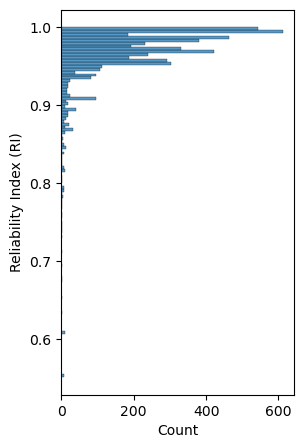

In [328]:
!mkdir -p  ../figures
(fig, ax) = plt.subplots(figsize=(3,5))
ax = sns.histplot(data=zdf[~zdf.roothog_id.isin({'singleton', 'filtered'})], y='reliability_index', ax=ax)
ax.set_ylabel('Reliability Index (RI)')
#plt.savefig('../figures/ri_dist_carotenoid.png', bbox_inches='tight')
#plt.savefig('../figures/ri_dist_carotenoid.pdf', bbox_inches='tight')

In [330]:
carotenoid_preds

,query_accession,reference_id,model_key,distance,reliability_index,distance_metric,uniprot_accession,go_id,category,go_description,evidence_codes,subhog_id,roothog_id
306,TS204Solyc_TS204_07T002173.1,42383,Prot-T5,0.011911,0.988089,cosine,O24023,GO:0016123,P,xanthophyll biosynthetic process,IMP,HOG:0037743.1b,HOG:0037743
316,TS204Solyc_TS204_07T002173.1,42383,Prot-T5,0.011911,0.988089,cosine,O24023,GO:1901812,P,beta-carotene biosynthetic process,IMP,HOG:0037743.1b,HOG:0037743
741,TS204Solyc_TS204_06T002371.1,47989,Prot-T5,0.014378,0.985622,cosine,K4C9E2,GO:0016123,P,xanthophyll biosynthetic process,IDA,HOG:0008619.4c,HOG:0008619
759,TS204Solyc_TS204_12T001558.1,75712,Prot-T5,0.014458,0.985542,cosine,K4DEY3,GO:0016123,P,xanthophyll biosynthetic process,IMP,HOG:0029666,HOG:0029666
1532,TS204Solyc_TS204_04T000922.1,48344,Prot-T5,0.016681,0.983319,cosine,Q43415,GO:1901812,P,beta-carotene biosynthetic process,IDA,HOG:0008619.4d,HOG:0008619
...,...,...,...,...,...,...,...,...,...,...,...,...,...
212758,CAPA2PHT95342.1,19318,Ankh3-Large,0.047217,0.952783,cosine,Q38932,GO:0016117,P,carotenoid biosynthetic process,IMP,HOG:0009047,HOG:0009047
212759,CAPA2PHT95342.1,19318,Ankh3-Large,0.047217,0.952783,cosine,Q38932,GO:0016123,P,xanthophyll biosynthetic process,IGI,HOG:0009047,HOG:0009047
218022,CAPA2PHT90787.1,19318,Ankh3-Large,0.051531,0.948469,cosine,Q38932,GO:0016117,P,carotenoid biosynthetic process,IMP,HOG:0006828.2b,HOG:0006828
218023,CAPA2PHT90787.1,19318,Ankh3-Large,0.051531,0.948469,cosine,Q38932,GO:0016123,P,xanthophyll biosynthetic process,IGI,HOG:0006828.2b,HOG:0006828


In [333]:
ipr_pfam = pd.read_csv('../data/functional_predictions/interproscan/Tomato_dataset.with_Pfam.txt.gz', sep='\t', names=['query_accession', 'pfams'])

In [339]:
pfam_carotenoid_preds = pd.merge(carotenoid_preds, ipr_pfam, on='query_accession', how='left')

In [362]:
all_pfam = set()
for (root_hog, zzzdf) in pfam_carotenoid_preds[['roothog_id', 'pfams']].groupby('roothog_id'):
    pfams = set()
    for x in zzzdf.pfams:
        if x is np.nan:
            continue
        for y in x.split(';'):
            pfams.add(y)

    if len(pfams) > 0:
        print(root_hog, *sorted(pfams), sep='\t')
        all_pfam.update(pfams)

HOG:0000089	PF00940
HOG:0000114	PF01655
HOG:0000164	PF03328
HOG:0000231	PF02485
HOG:0002742	PF04674
HOG:0003950	PF01494
HOG:0004844	PF00254	PF01096
HOG:0005396	PF16113
HOG:0006828	PF14476
HOG:0006872	PF09809
HOG:0007715	PF01658	PF07994
HOG:0007929	PF00464
HOG:0007930	PF00006	PF00306
HOG:0007993	PF01593
HOG:0007994	PF03360
HOG:0008076	PF00291
HOG:0008308	PF13450
HOG:0008316	PF02153	PF03807
HOG:0008429	PF00223	PF00562
HOG:0008588	PF06979
HOG:0008619	PF00957	PF05834	PF13774
HOG:0008876	PF01588
HOG:0009047	PF02091
HOG:0009179	PF01466
HOG:0011175	PF14547
HOG:0012810	PF03364
HOG:0012861	PF03080
HOG:0012884	PF13450
HOG:0012886	PF10250
HOG:0012924	PF14736
HOG:0012960	PF00849	PF03030
HOG:0013138	PF02542
HOG:0014202	PF04414
HOG:0014214	PF14108
HOG:0014406	PF25070
HOG:0019632	PF00254	PF00923
HOG:0019668	PF00830
HOG:0024862	PF25279
HOG:0025149	PF01786
HOG:0025945	PF00361
HOG:0026174	PF23754
HOG:0026246	PF08743
HOG:0026255	PF05641
HOG:0029345	PF00067
HOG:0029484	PF01174
HOG:0029486	PF01012
HOG:0029

In [369]:
from bioservices import InterPro

In [370]:
p = InterPro(verbose=False)

In [374]:
pfam2name = {}
for x in tqdm(all_pfam):
    pfam2name[x] = p.get_member_database_entry('pfam', x)['metadata']['name']['name']

  0%|          | 0/174 [00:00<?, ?it/s]

In [379]:
def gen():
    for (root_hog, zzzdf) in pfam_carotenoid_preds[['roothog_id', 'pfams']].groupby('roothog_id'):
        if root_hog in {'filtered', 'singleton'}:
            continue
        pfams = set()
        for x in zzzdf.pfams:
            if x is np.nan:
                continue
            for y in x.split(';'):
                pfams.add(y)
    
        if len(pfams) > 0:
            r = {'roothog_id': root_hog}
            for i,x in enumerate(sorted(pfams)):
                r[f'pfam_{i}'] = '{} ({})'.format(pfam2name[x], x)
            yield r

pfam_res_df = pd.DataFrame(gen())

In [388]:
pfam_res_df.to_csv('temp.tsv', sep='\t', index=False)

In [347]:
import numpy as np



set()

In [338]:
help(pd.merge)

Help on function merge in module pandas.core.reshape.merge:

merge(left: 'DataFrame | Series', right: 'DataFrame | Series', how: 'MergeHow' = 'inner', on: 'IndexLabel | AnyArrayLike | None' = None, left_on: 'IndexLabel | AnyArrayLike | None' = None, right_on: 'IndexLabel | AnyArrayLike | None' = None, left_index: 'bool' = False, right_index: 'bool' = False, sort: 'bool' = False, suffixes: 'Suffixes' = ('_x', '_y'), copy: 'bool | None' = None, indicator: 'str | bool' = False, validate: 'str | None' = None) -> 'DataFrame'
    Merge DataFrame or named Series objects with a database-style join.
    
    A named Series object is treated as a DataFrame with a single named column.
    
    The join is done on columns or indexes. If joining columns on
    columns, the DataFrame indexes *will be ignored*. Otherwise if joining indexes
    on indexes or indexes on a column or columns, the index will be passed on.
    When performing a cross merge, no column specifications to merge on are
    allo